In [1]:
import jax
jax.config.update("jax_enable_x64", True)

from jax import jit, grad, jacobian, vmap, lax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt

from functools import partial
import time

In [2]:
mol = 'heh+'
basis = '6-31g'
method = 'fci'

In [3]:
dt = 0.01
T = 200.0
numsteps = int(np.ceil(T/dt))
print("numsteps = " + str(numsteps))

# field parameters: 
freq = 0.29 / (2*np.pi)  # frequency
amp = 0.5                # amplitude
ncyc = 5.0               # number of cycles to keep field on

# Let us take the field to be
# amp * sin(2 * pi * freq * t) so that the period is T = 1 / freq.
# Thus we will keep the field on for ncyc * T = ncyc / freq a.u.,
# which translates into ncyc / (dt * freq) time steps.

stepoff = int(np.ceil(ncyc / (dt * freq)))
print("field will be on for " + str(stepoff) + " time steps")

numsteps = 20000
field will be on for 10834 time steps


In [4]:
fname = method + '_' + mol + '_' + basis + '.npz'
print(fname)

fci_heh+_6-31g.npz


In [5]:
prefix = './psi4data/'
psi4data = np.load(prefix + fname)

In [6]:
psi4data['ham']

array([-2.93231075, -2.14209775, -1.96404284, -1.41552484, -1.35282616,
       -0.99688458, -0.6654203 , -0.57566881, -0.08763561,  0.08179299,
        0.21715018,  0.44229521,  0.69881705,  0.90207512,  1.09915501,
        1.42731566])

In [7]:
print(list(psi4data.keys()))

['C', 'S', 'AOdipmat', 'CIdimatz', 'Bten', 'ham']


In [8]:
drcCI = psi4data['Bten'].shape[0]
drc = psi4data['Bten'].shape[2]

In [9]:
# propagate starting with a particular initial condition ic
statesCI = np.zeros((drcCI, numsteps+1), dtype=np.complex128)
statesCI[0,0] = 1.0
cnt = 0

# store the propagators
# could modify this later to store only when field is on
fieldprop = np.zeros((drcCI, drcCI, numsteps), dtype=np.complex128)

# propagate solution forward in time
for j in range(numsteps):
    h = np.diag(psi4data['ham'])
    if (j < stepoff):
        field = amp * np.sin(2*np.pi*freq*j*dt)
        print("Time step j = " + str(j) + "; field strength = " + str(field)) 
        h += field * psi4data['CIdimatz']
        dd, vv = np.linalg.eigh(h)
        prop = vv @ np.diag(np.exp(-1j * dt * dd)) @ vv.conj().T
    else:
        prop = np.diag(np.exp(-1j * dt * psi4data['ham']))
    
    fieldprop[:, :, j] = prop
    statesCI[:,j+1] = prop @ statesCI[:,j]

Time step j = 0; field strength = 0.0
Time step j = 1; field strength = 0.0014499979675841879
Time step j = 2; field strength = 0.0028999837406940144
Time step j = 3; field strength = 0.0043499451249576744
Time step j = 4; field strength = 0.005799869926208473
Time step j = 5; field strength = 0.0072497459505873755
Time step j = 6; field strength = 0.008699561004645563
Time step j = 7; field strength = 0.010149302895446978
Time step j = 8; field strength = 0.011598959430670863
Time step j = 9; field strength = 0.0130485184187143
Time step j = 10; field strength = 0.014497967668794742
Time step j = 11; field strength = 0.015947294991052543
Time step j = 12; field strength = 0.01739648819665346
Time step j = 13; field strength = 0.018845535097891178
Time step j = 14; field strength = 0.0202944235082898
Time step j = 15; field strength = 0.021743141242706335
Time step j = 16; field strength = 0.02319167611743317
Time step j = 17; field strength = 0.02464001595030055
Time step j = 18; fiel

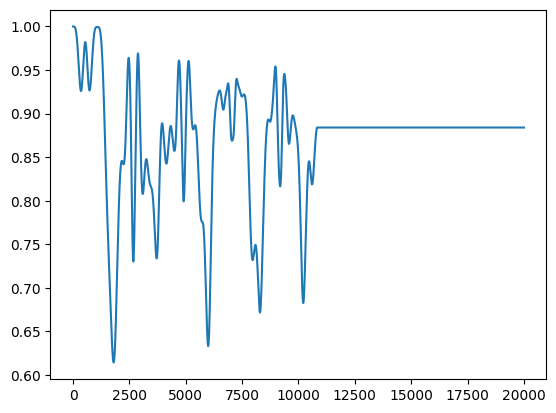

In [10]:
plt.plot(np.abs(statesCI[0,:]))
plt.show()

In [11]:
# compute and store all 1-RDMs
Bmat = psi4data['Bten'].reshape((drcCI**2, drc**2))
BmatT = Bmat.T
truerdms = np.zeros((numsteps+1, drc, drc), dtype=np.complex128)
for j in range(numsteps+1):
    a = statesCI[:, [j]]
    trueden = a @ a.conj().T
    truerdms[j, :, :] = (BmatT @ trueden.reshape((-1))).reshape((drc, drc))

In [12]:
# check at once whether all 1-RDM traces are close to 2
print( np.mean(np.abs(np.einsum('jaa->j',truerdms) - 2)) )

1.3498328221385057e-12


In [13]:
# BmatT has drcCI**2 columns
# let us figure out which of these columns are actually non-trivial
colnorms = np.array( list( map( lambda j : np.linalg.norm(BmatT[:,j]), np.arange(drcCI**2, dtype=np.int16) ) ) )
goodcols = np.where(colnorms > 1e-14)[0]
badcols = np.where(colnorms <= 1e-14)[0]
diagcols = np.where(np.eye(drcCI).reshape((-1)))[0]
fincols = goodcols[~np.isin(goodcols, diagcols)]

In [14]:
zerostates = []
for j in range(drcCI):
    if np.linalg.norm(statesCI[j,:]) < 1e-10:
        zerostates.append(j)

In [15]:
print(zerostates)

[1, 3, 5, 8, 10, 13]


In [16]:
truedens = np.einsum('in,jn->ijn',statesCI,statesCI.conj())
truedenflat = truedens.reshape((drcCI**2, numsteps+1))

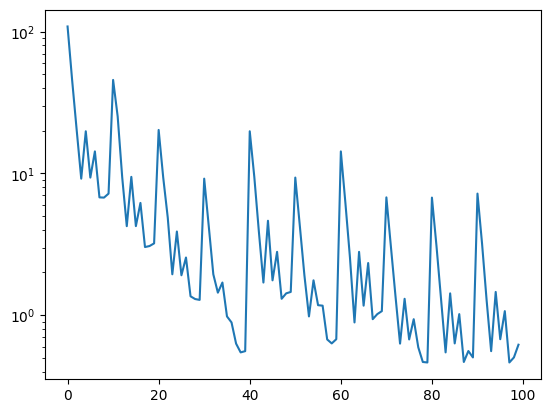

In [17]:
truedencolnorms = np.array( list( map( lambda j : np.linalg.norm(truedenflat[j,:]), np.arange(drcCI**2, dtype=np.int16) ) ) )
truedengoodcols = np.where(truedencolnorms > 1e-10)[0]
plt.semilogy(truedencolnorms[truedengoodcols])
plt.show()

In [18]:
# J = 1135
# ell = 400
# Cmat = np.eye(drcCI, drcCI)
# BtildeT = BmatT[:, truedengoodcols]
# bigmat = np.copy(BtildeT)

# for j in range(1, ell+1):
#     Cmat = Cmat @ fieldprop[:,:,J - j].conj().T
#     Amat = Cmat.conj().T
#     bigprop = np.kron( Cmat.T, Amat )
#     bigmat = np.concatenate([bigmat, (BmatT @ bigprop)[:, truedengoodcols]], axis=0)

# a = statesCI[:, [J]]
# trueden = a @ a.conj().T
# truedentilde = trueden.reshape((-1))[truedengoodcols]
# trueq = bigmat @ truedentilde
# err = 0
# for j in range(ell+1):
#     si = j*drc**2
#     ei = (j+1)*drc**2
#     err += np.linalg.norm( truerdms[:,:,J-j].reshape((-1)) - trueq[si:ei])

# print(err)
# print(np.linalg.matrix_rank(bigmat))

In [19]:
fieldpropJ = jnp.array(fieldprop)
tdgc = jnp.array(truedengoodcols, dtype=jnp.int32)
print(tdgc.shape[0])
BmatT = jnp.array(BmatT)
BtildeT = BmatT[:, truedengoodcols]
zerostatesJ = jnp.array(zerostates, dtype=jnp.int32)

W0422 20:55:55.154852   60366 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0422 20:55:55.157834   60259 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


100


In [20]:
# # build right product: bigmat against reduced vec{P(t)}
# def rightprod(redvecp, J):
#     fullvecp = jnp.zeros(drcCI**2, dtype=jnp.complex128)
#     fullvecp = fullvecp.at[tdgc].set(redvecp)
#     fullp = fullvecp.reshape((drcCI, drcCI))
#     out = [ BtildeT @ redvecp ]
#     Cmat = jnp.eye(drcCI)
#     for j in range(1, ell+1):
#         Cmat = Cmat @ fieldpropJ[:,:,J - j].conj().T
#         backden = Cmat.T @ fullp @ Cmat.conj()
#         out.append( BtildeT @ backden.reshape((-1))[tdgc] )
#     return jnp.concatenate(out)

In [21]:
# # build left product: bigmat.T against vec{Q(t)}
# def leftprod(vecq, J):
#     drc2 = drc**2
#     out = []
#     Cmat = jnp.eye(drcCI)
#     out = vecq[:drc2] @ BtildeT
#     for j in range(1, ell+1):
#         fullpvec = vecq[j*drc2 : (j+1)*drc2] @ BmatT
#         fullp = fullpvec.reshape((drcCI, drcCI))
#         Cmat = Cmat @ fieldpropJ[:,:,J - j].conj().T
#         Amat = Cmat.conj().T
#         out += (Cmat @ fullp @ Amat).reshape((-1))[tdgc]
#     return out

In [22]:
BmatTT = BmatT.reshape((drc**2, drcCI, drcCI))
def buildbigmat(J):
    drc2 = drc**2
    out = []
    Cmat = jnp.eye(drcCI)
    out = [BtildeT]
    for j in range(1, ell+1):
        Cmat = Cmat @ fieldpropJ[:,:,J - j].conj().T
        Amat = Cmat.conj().T
        out.append( (Cmat @ BmatTT @ Amat).reshape((drc**2, drcCI**2))[:,tdgc] )
    return jnp.concatenate(out, axis=0)

In [23]:
# formbigmatR = jit(vmap(rightprod, in_axes=(0, None)))
# formbigmat = jit(vmap(leftprod, in_axes=(0, None)))

jbuildbigmat = jit(buildbigmat)

In [24]:
ell = 100

In [25]:
truerdmsJ = jnp.array(truerdms[:(ell+1),:,:])

In [26]:
predrdms = jnp.concatenate([truerdmsJ, 
                            jnp.zeros((numsteps-ell, drc, drc), dtype=jnp.complex128)],
                            axis=0)

In [27]:
np.linalg.norm(truedens[:,:,11]-fieldprop[:,:,10].T@truedens[:,:,10]@fieldprop[:,:,10].conj().T)

np.float64(1.112565003099672e-16)

In [54]:
start = time.time()
for j in range(ell, ell+1):
    trueq = jnp.flip(predrdms[j-ell : j+1, :, :], axis=0).reshape((-1))
    bigmat = jbuildbigmat(j)
    reconp = jnp.linalg.pinv(bigmat) @ trueq
    fullvecp = jnp.zeros(drcCI**2, dtype=jnp.complex128)
    fullvecp = fullvecp.at[tdgc].set(reconp)
    fullp = fullvecp.reshape((drcCI, drcCI))
    nextp = fieldprop[:,:,j].T @ fullp @ fieldprop[:,:,j].conj().T
    predrdms = predrdms.at[j+1].set( (BmatT @ nextp.reshape((-1))).reshape((drc, drc)))
end = time.time()

print(end - start)

0.023089885711669922


In [42]:
N = 32000
print(np.mean(np.abs(predrdms[:N] - truerdms[:N])))

0.15498234874824787


In [67]:
atest = jnp.linalg.solve(jnp.vstack([fullp[:-1,:], jnp.eye(drcCI)[0,:]]) - jnp.eye(drcCI), 
                         jnp.eye(drcCI)[:,-1])